In [ ]:
!pip install thefuzz[speedup]
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from thefuzz.process import extractOne as best

In [ ]:
# 1. Rutas de acceso a GitHub Raw
linkGit = 'https://raw.githubusercontent.com/TareasDatosEspaciales/MOBILES/main/'
someDataLink = 'some_dataworld.csv'

In [ ]:
# 2. Carga de archivos

#Descarga el mapa base en formato GeoPackage desde GitHub leyendo la capa de países.
countries = gpd.read_file(linkGit + 'worldMaps.gpkg', layer='countries')
#Descarga la tabla de datos numéricos desde GitHub.
someData = pd.read_csv(linkGit + someDataLink)


In [ ]:
# 3. Homogeneización del nombre de la columna para la fusión
countries.rename(columns={'COUNTRY': 'Country'}, inplace=True)
# Convertir a mayúsculas para homologar formatos y evitar fallos al cruzar datos (merge)
countries['Country'] = countries.Country.str.upper()

In [ ]:
# 4. Ajuste difuso de nombres de países (Fuzzy Matching)
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)
changesToDF = {country: best(country, onlyGDF)[0] for country in onlyDF}
someData.replace(to_replace={'Country': changesToDF}, inplace=True)

In [ ]:
# 5. Fusión de datos y filtrado para América del norte, sudamérica, centroamércia y el Caribe
theMapAndData = countries.merge(someData, on='Country')
regiones_america = ['NORTH AMERICA', 'SOUTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN']
America = theMapAndData[theMapAndData.region.isin(regiones_america)].copy()

In [ ]:
# 6. Reproyecta el mapa al sistema World Mercator Equal Area (EPSG:8857) para mantener proporciones geométricas correctas.
America_8857 = America.to_crs(8857)

In [ ]:
print("¡Carga y procesamiento de datos para América completado!")
np.random.seed(12345) # Semilla fija para reproducibilidad

¡Carga y procesamiento de datos para América completado!


In [ ]:
#Mapa 1 - Densidad de Puntos (Dot Density Map)

# Función para generar puntos dentro de los polígonos según la variable 'mobiles'

def gen_points(gdf, col_name, factor=1_000_000):
    points = []
    for idx, row in gdf.iterrows():
        num_points = int(row[col_name] / factor)
        if num_points > 0:
            minx, miny, maxx, maxy = row.geometry.bounds
            cnt = 0
            while cnt < num_points:
                pnt = gpd.points_from_xy([np.random.uniform(minx, maxx)], [np.random.uniform(miny, maxy)])[0]
                if row.geometry.contains(pnt):
                    points.append(pnt)
                    cnt += 1
    return gpd.GeoDataFrame(geometry=points, crs=gdf.crs)

In [ ]:
# Generación de puntos (1 punto = 1,000,000 de usuarios mobiles)
dots = gen_points(America_8857, 'mobiles', factor=1000000)

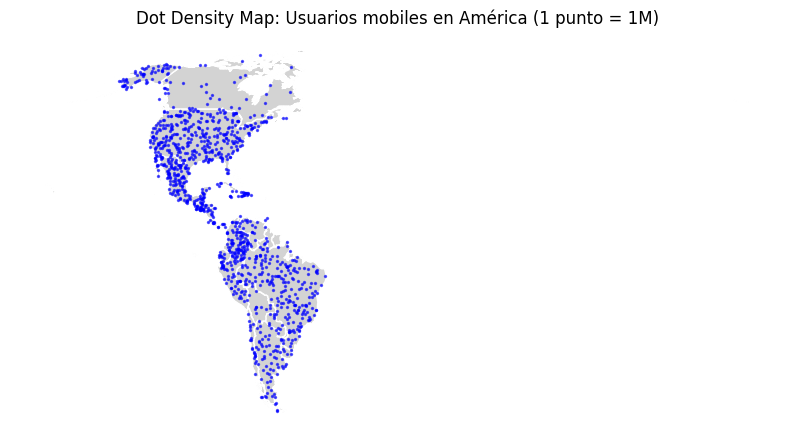

In [ ]:
# Graficar DDM
fig, ax = plt.subplots(figsize=(10, 10))
America_8857.plot(ax=ax, color='lightgrey', edgecolor='white')
dots.plot(ax=ax, color='blue', markersize=2, alpha=0.6)
plt.title("Dot Density Map: Usuarios mobiles en América (1 punto = 1M)")
plt.axis('off')
plt.show()

In [ ]:
#Mapa 2 - Mapa de Símbolos Proporcionales (PSM)

# Cálculo de puntos representativos (centroides estables)
America_8857_centroids = America_8857.copy()
America_8857_centroids["geometry"] = America_8857.representative_point()

In [ ]:
# Identificación de outliers para la variable 'mobiles'
boxplotInfo = America_8857_centroids.boxplot(column='mobiles', return_type="dict")
outliers = boxplotInfo['fliers'][0].get_ydata()
plt.close()

In [ ]:
# Clasificación binaria de outliers (America_out_atipico=1 o America_no_out_noAtipico=0)
America_8857_centroids['mobiles_outlier'] = America_8857_centroids.mobiles.isin(outliers) * 1
America_out = America_8857_centroids[America_8857_centroids.mobiles_outlier == 1].copy()
America_no_out = America_8857_centroids[America_8857_centroids.mobiles_outlier == 0].copy()

In [ ]:
# Ajuste del tamaño de símbolos usando raíz cuadrada, define el tamaño proporcional del cículo
America_out['size'] = America_out['mobiles'].apply(lambda x: x**0.5 / 100)
America_no_out['size'] = America_no_out['mobiles'].apply(lambda x: x**0.5 / 100)

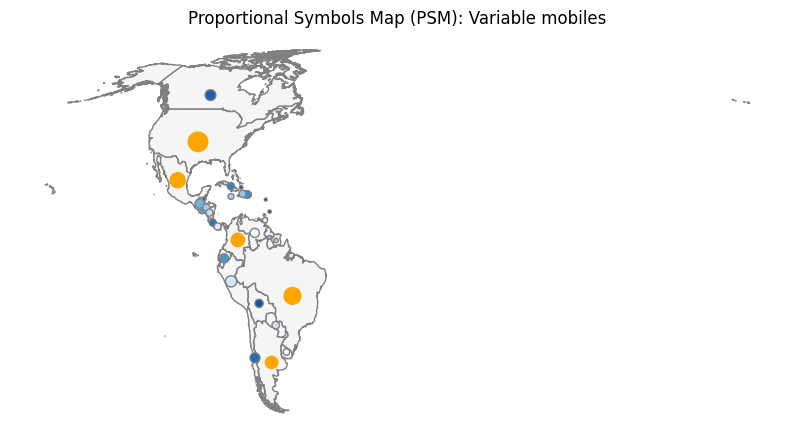

In [ ]:
# Graficar PSM Outliers en Naranja_comportamiento muy alejado del resto del continente, burbujas normales en azul_comportamiento esperado
base = America_8857.plot(color='whitesmoke', edgecolor='grey', figsize=(10, 10))
America_no_out.plot(
    ax=base,
    markersize=America_no_out['size'],
    edgecolor='grey',
    c=America_no_out['size'],
    cmap='Blues_r' # Mayor tono de azul, mayores usuarios de celulares
)
America_out.plot(
    ax=base,
    markersize=America_out['size'],
    color='orange'
)
plt.title("Proportional Symbols Map (PSM): Variable mobiles")
plt.axis('off')
plt.show()

In [ ]:
#Mapa Coroplético (Fisher-Jenks)

# Cálculo de densidad: tasa de usuarios mobiles por km²
America_8857['mobiles_rate'] = America_8857['mobiles'] / (America_8857.geometry.area / 10**6)

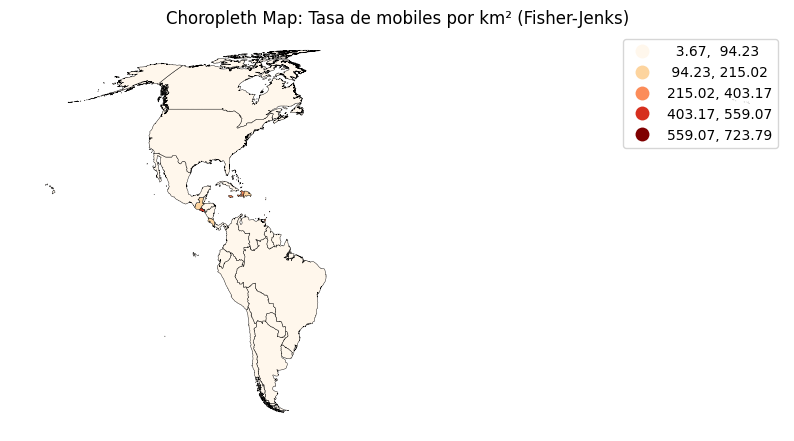

In [ ]:
# Graficar mapa coroplético con clasificación de Fisher-Jenks (5 clases)
fig, ax = plt.subplots(figsize=(10, 10))
America_8857.plot(
    column='mobiles_rate',
    scheme='FisherJenks',
    k=5, #Dividido en 5 grupos
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)
plt.title("Choropleth Map: Tasa de mobiles por km² (Fisher-Jenks)")
plt.axis('off')
plt.show()